# M2 — Constitutional Text Analysis

Thesis-quality analyses and figures for:
- **Ch.1 S1**: Sovereignty vs. identity rhetoric in preambles
- **Ch.1 S2**: Naming analysis — how constitutions refer to sub-state groups
- **Ch.5**: Self-determination classification of 54 constitutions

Figures exported to `data/figures/` for thesis PDF inclusion.

In [1]:
import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Shared thesis style & bilingual labels
sys.path.insert(0, str(Path('..') / 'scripts'))
from figure_style import *
apply_style()

PROJECT = Path('..') if Path('../src/data.js').exists() else Path('.')
FIG_DIR = PROJECT / 'data' / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# Load data
with open(PROJECT / 'src' / 'data.js') as f:
    DATA = json.loads(f.read().split('const DATA = ')[1].rstrip(';\n'))
with open(PROJECT / 'scripts' / 'country_mapping.json') as f:
    EN_TO_FR = json.load(f)
with open(PROJECT / 'data' / 'constitution_corpus' / '_extraction_stats.json') as f:
    stats = json.load(f)

heritage_map = DATA['colonial_heritage']
def get_heritage(en_country):
    fr = EN_TO_FR.get(en_country)
    return heritage_map.get(fr, 'other') if fr else 'other'

def get_fr_name(en_country):
    return EN_TO_FR.get(en_country, en_country)

# Load texts
CORPUS = PROJECT / 'data' / 'constitution_corpus'
PREAMBLES = PROJECT / 'data' / 'preamble_corpus'

texts = {}
for s in stats:
    texts[s['country']] = (CORPUS / f"{Path(s['file']).stem}.txt").read_text(encoding='utf-8')

preamble_texts = {}
for s in stats:
    if s['has_preamble']:
        p = PREAMBLES / f"{Path(s['file']).stem}.txt"
        if p.exists():
            preamble_texts[s['country']] = p.read_text(encoding='utf-8')

print(f'Loaded {len(texts)} constitutions, {len(preamble_texts)} preambles')

Loaded 54 constitutions, 49 preambles


> **Translation caveat:** All constitution texts are English translations from constituteproject.org. Only the 19 anglophone constitutions are in their original language. Binary detection (term present/absent) is reliable; cross-heritage frequency comparisons should be interpreted with caution as translation artifacts may affect raw counts. The COMMENTAIRE analysis (same language, same coder) provides a methodologically cleaner comparison. See `docs/linguistic_decisions.md`.

---
## 1. Ch.1 S1 — Sovereignty vs. Identity in Preambles

The thesis argues that sovereignty and identity are competing forces in African constitutional law. The preambles are where this tension is most visible.

In [2]:
# Define keyword groups
SOV_KEYWORDS = [
    'sovereignty', 'sovereign', 'unity', 'indivisible',
    'territorial integrity', 'national unity', 'unitary',
]
ID_KEYWORDS = [
    'people', 'peoples', 'ethnic', 'tribe', 'tribal',
    'diversity', 'community', 'communities', 'indigenous',
    'minority', 'minorities', 'identity', 'tradition',
    'cultural heritage', 'customary',
]

def count_keywords(text, keywords):
    text_lower = text.lower()
    return sum(len(re.findall(r'\b' + re.escape(kw) + r'\b', text_lower)) for kw in keywords)

# Analyze preambles
rows = []
for country, text in preamble_texts.items():
    n_words = len(text.split())
    if n_words < 20:
        continue
    sov = count_keywords(text, SOV_KEYWORDS)
    ident = count_keywords(text, ID_KEYWORDS)
    h = get_heritage(country)
    rows.append({
        'country': country, 'fr_name': get_fr_name(country),
        'heritage': h, 'words': n_words,
        'sov_count': sov, 'id_count': ident,
        'sov_per1k': sov / n_words * 1000,
        'id_per1k': ident / n_words * 1000,
    })

pa = pd.DataFrame(rows)
pa['balance'] = pa['id_per1k'] - pa['sov_per1k']  # positive = identity-dominant
print(f'Preambles analyzed: {len(pa)}')

Preambles analyzed: 49


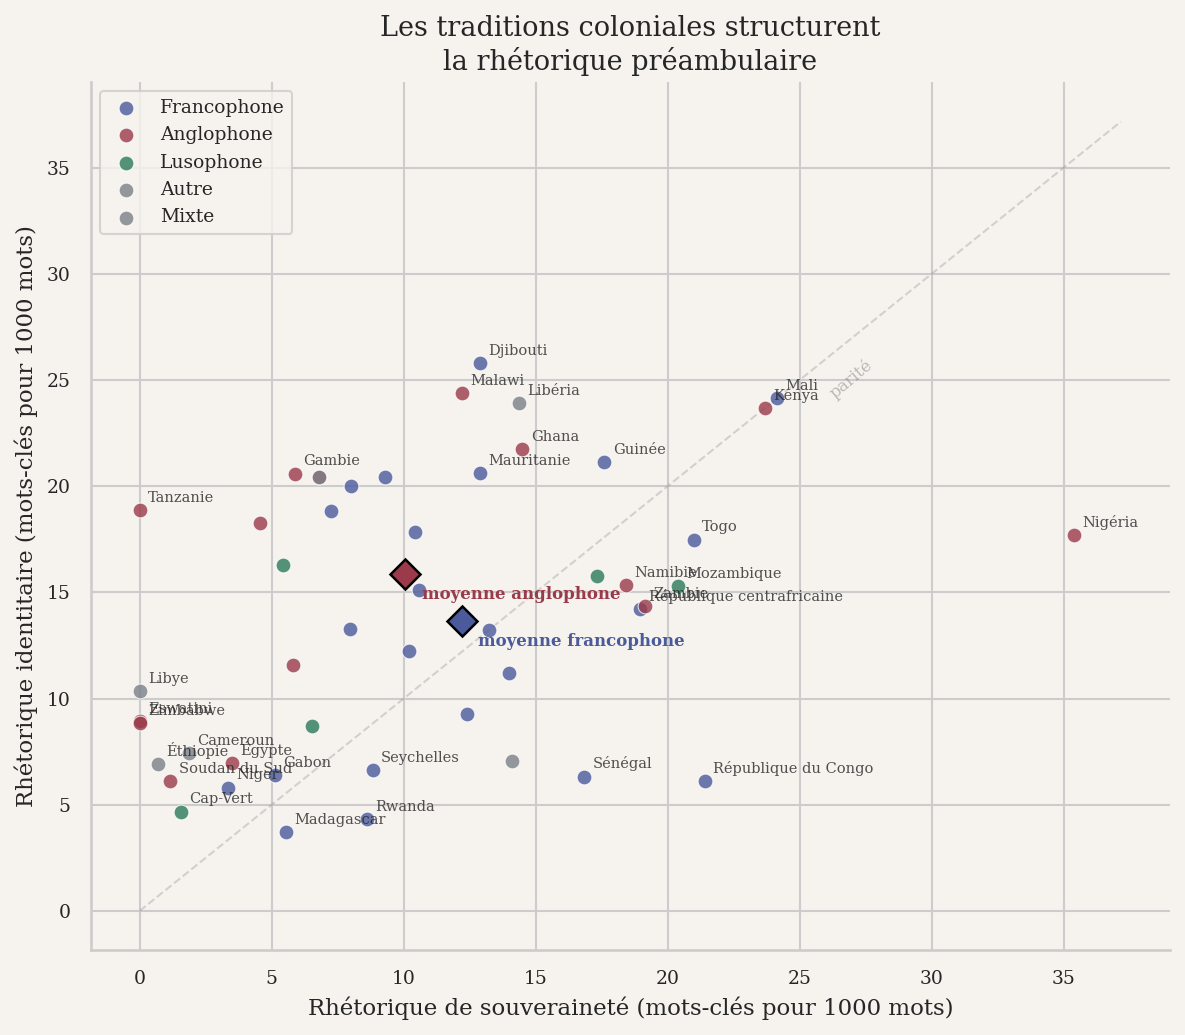

Saved to ../data/figures


In [3]:
# FIGURE 1: Sovereignty vs Identity scatter (preambles)
for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(8, 7))

    for h in H_ORDER:
        subset = pa[pa['heritage'] == h]
        ax.scatter(subset['sov_per1k'], subset['id_per1k'],
                  c=HC[h], s=50, alpha=0.8, edgecolors='white', linewidth=0.5,
                  label=hl(h, lang), zorder=3)

    # Annotate only extreme outliers (top/bottom 20% by either axis)
    sov_q80, sov_q20 = pa['sov_per1k'].quantile(0.8), pa['sov_per1k'].quantile(0.2)
    id_q80, id_q20 = pa['id_per1k'].quantile(0.8), pa['id_per1k'].quantile(0.2)
    for _, row in pa.iterrows():
        is_outlier = (row['sov_per1k'] > sov_q80 or row['sov_per1k'] < sov_q20
                      or row['id_per1k'] > id_q80 or row['id_per1k'] < id_q20)
        if is_outlier:
            ax.annotate(row['fr_name'], (row['sov_per1k'], row['id_per1k']),
                       fontsize=7, alpha=0.8, xytext=(4, 4), textcoords='offset points')

    # Diagonal: parity line
    lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.3, linewidth=1)
    ax.text(lim * 0.7, lim * 0.65, t('preamble_parity', lang), color='gray', fontsize=8, alpha=0.5, rotation=40)

    # Heritage group means
    for h in ['francophone', 'anglophone']:
        subset = pa[pa['heritage'] == h]
        mx, my = subset['sov_per1k'].mean(), subset['id_per1k'].mean()
        ax.plot(mx, my, 'D', color=HC[h], markersize=10, markeredgecolor='black', markeredgewidth=1.2, zorder=5)
        ax.annotate(t('preamble_mean_fmt', lang).format(hl(h, lang).lower()), (mx, my),
                   fontsize=8, fontweight='bold', color=HC[h],
                   xytext=(8, -12), textcoords='offset points')

    ax.set_xlabel(t('preamble_sov_id_xlabel', lang))
    ax.set_ylabel(t('preamble_sov_id_ylabel', lang))
    ax.set_title(t('preamble_sov_id_title', lang), fontsize=13)
    ax.legend(loc='upper left', fontsize=9)

    plt.tight_layout()
    save_fig(fig, 'ch1s1_preamble_sovereignty_identity', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print(f'Saved to {FIG_DIR}')

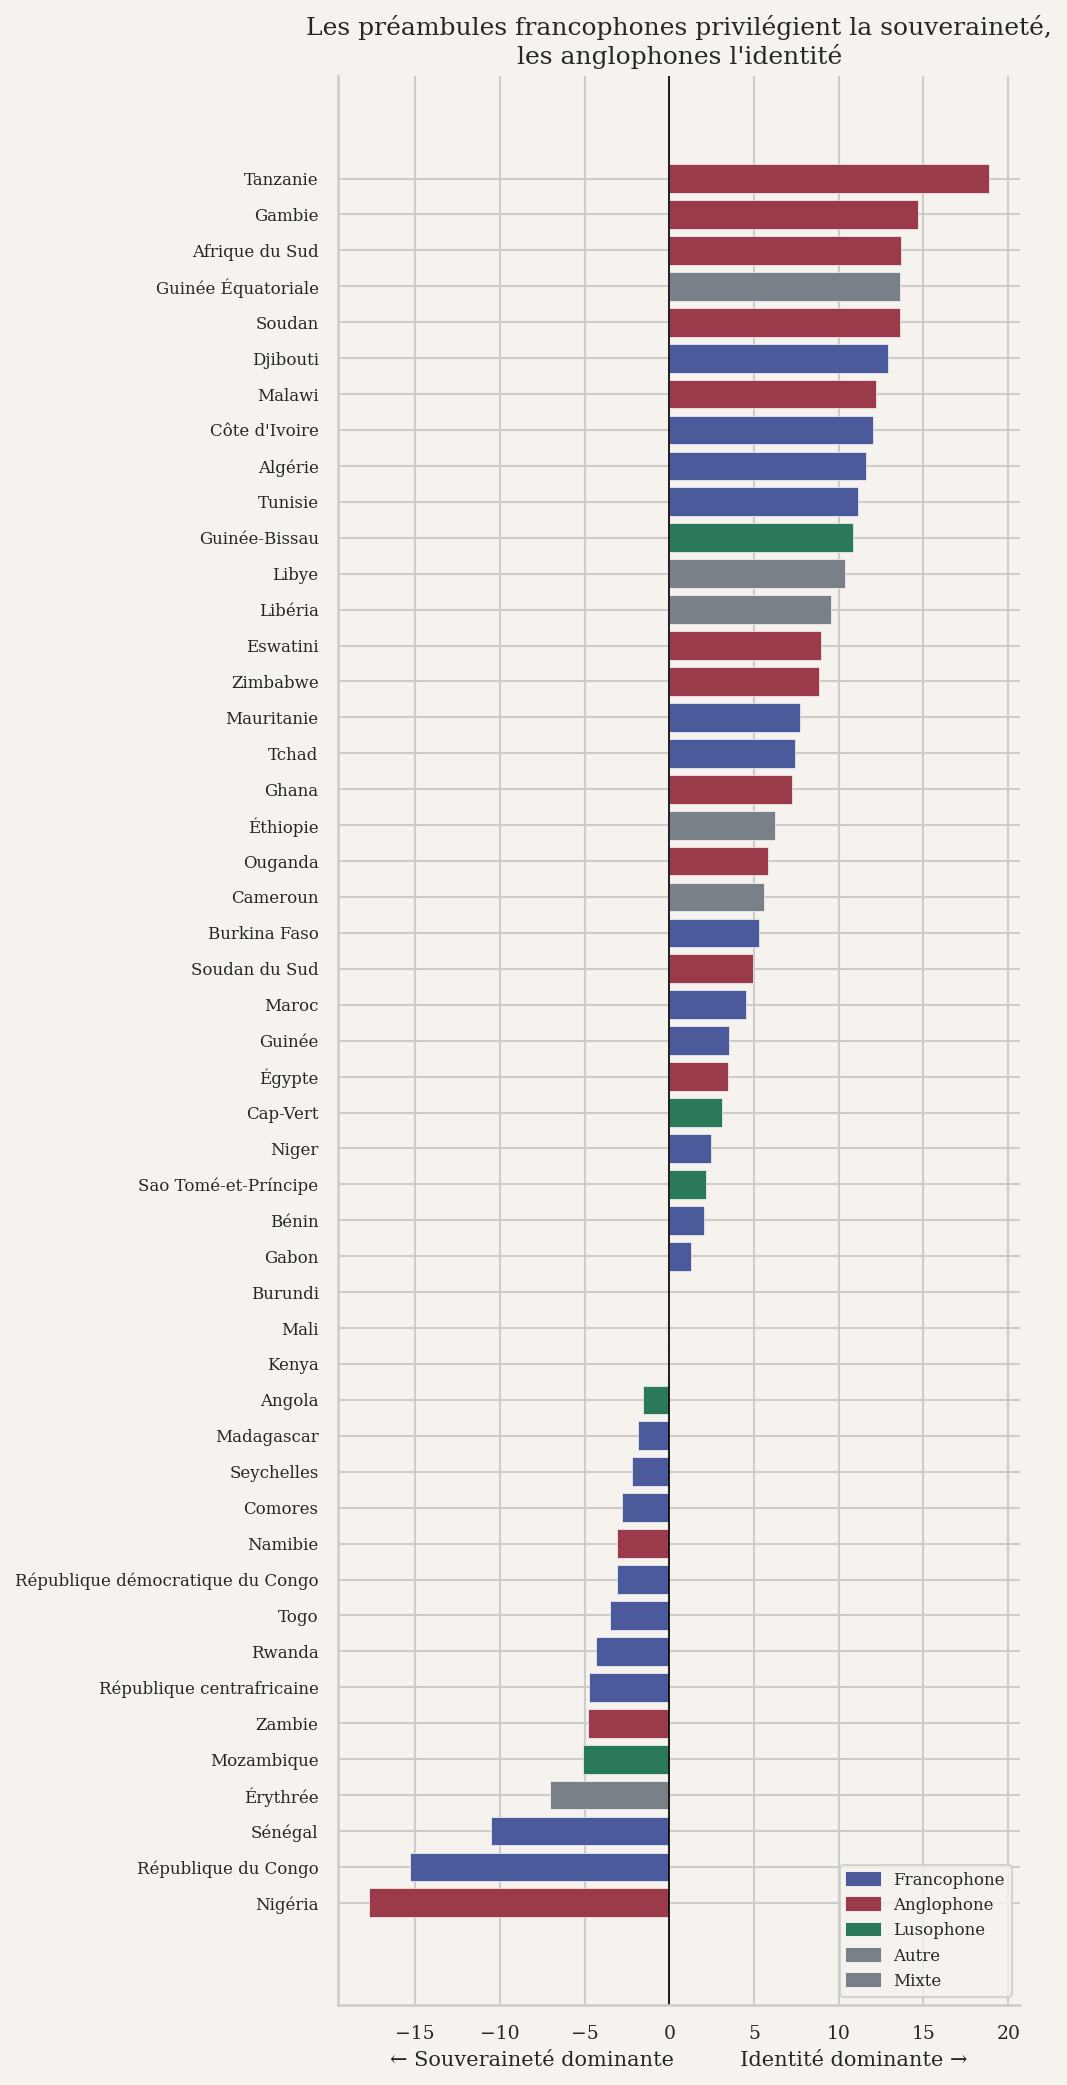

In [4]:
# FIGURE 2: Balance bar chart (identity − sovereignty per 1k words), sorted
pa_sorted = pa.sort_values('balance')

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(7, 14))
    colors = [HC.get(h, HC['other']) for h in pa_sorted['heritage']]
    ax.barh(range(len(pa_sorted)), pa_sorted['balance'], color=colors, edgecolor='white', linewidth=0.3)
    ax.set_yticks(range(len(pa_sorted)))
    ax.set_yticklabels(pa_sorted['fr_name'], fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel(t('preamble_balance_xlabel', lang), fontsize=10)
    ax.set_title(t('preamble_balance_title', lang), fontsize=12)

    legend_patches = [mpatches.Patch(color=HC[h], label=hl(h, lang)) for h in H_ORDER]
    ax.legend(handles=legend_patches, loc='lower right', fontsize=8)

    plt.tight_layout()
    save_fig(fig, 'ch1s1_preamble_balance', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

In [5]:
# Heritage group statistics
print('Heritage group preamble rhetoric (per 1000 words):')
print()
for h in H_ORDER:
    subset = pa[pa['heritage'] == h]
    if len(subset) == 0:
        continue
    print(f'  {hl(h):15s} (n={len(subset):2d}):')
    print(f'    Sovereignty: mean={subset["sov_per1k"].mean():.1f}, median={subset["sov_per1k"].median():.1f}')
    print(f'    Identity:    mean={subset["id_per1k"].mean():.1f}, median={subset["id_per1k"].median():.1f}')
    print(f'    Balance:     mean={subset["balance"].mean():.1f} ({"identity-dominant" if subset["balance"].mean() > 0 else "sovereignty-dominant"})')
    print()

Heritage group preamble rhetoric (per 1000 words):

  Francophone     (n=23):
    Sovereignty: mean=12.2, median=10.6
    Identity:    mean=13.7, median=13.3
    Balance:     mean=1.5 (identity-dominant)

  Anglophone      (n=15):
    Sovereignty: mean=10.1, median=5.9
    Identity:    mean=15.9, median=17.7
    Balance:     mean=5.8 (identity-dominant)

  Lusophone       (n= 5):
    Sovereignty: mean=10.3, median=6.5
    Identity:    mean=12.2, median=15.3
    Balance:     mean=1.9 (identity-dominant)

  Autre           (n= 5):
    Sovereignty: mean=7.2, median=6.8
    Identity:    mean=13.7, median=10.3
    Balance:     mean=6.5 (identity-dominant)

  Mixte           (n= 1):
    Sovereignty: mean=1.9, median=1.9
    Identity:    mean=7.4, median=7.4
    Balance:     mean=5.6 (identity-dominant)



---
## 2. Ch.1 S1 — "Indivisible" as Heritage Marker

The corpus EDA found that "indivisible" is the sharpest heritage discriminator (70% francophone vs 21% anglophone). Let's map it.

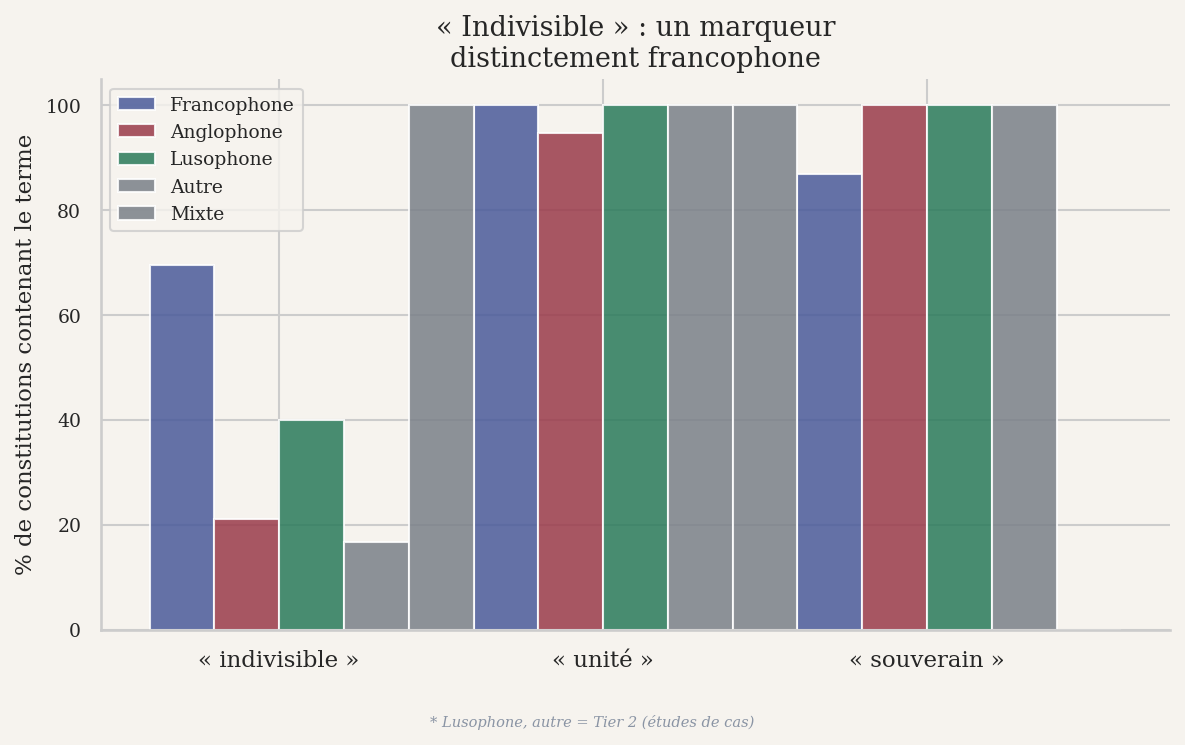

Key finding: "indivisible" presence by heritage:
  Francophone    : 16/23 (70%)
  Anglophone     : 4/19 (21%)
  Lusophone      : 2/5 (40%)
  Autre          : 1/6 (17%)
  Mixte          : 1/1 (100%)


In [6]:
# Analyze "indivisible" across full texts
indiv_rows = []
for country, text in texts.items():
    text_lower = text.lower()
    has_indivisible = bool(re.search(r'\bindivisible\b', text_lower))
    has_unity = bool(re.search(r'\bunity\b', text_lower))
    has_sovereign = bool(re.search(r'\bsovereign\b', text_lower))
    indiv_rows.append({
        'country': country, 'fr_name': get_fr_name(country),
        'heritage': get_heritage(country),
        'indivisible': has_indivisible,
        'unity': has_unity,
        'sovereign': has_sovereign,
    })

indiv = pd.DataFrame(indiv_rows)

# FIGURE 3: Sovereignty markers by heritage (grouped bar)
markers = ['indivisible', 'unity', 'sovereign']

heritage_rates = {}
for h in H_ORDER:
    subset = indiv[indiv['heritage'] == h]
    if len(subset) == 0:
        continue
    heritage_rates[h] = {m: subset[m].mean() * 100 for m in markers}

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(markers))
    width = 0.2
    for i, h in enumerate([h for h in H_ORDER if h in heritage_rates]):
        vals = [heritage_rates[h][m] for m in markers]
        ax.bar(x + i * width, vals, width, label=hl(h, lang), color=HC[h], alpha=0.85)

    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(t('sov_marker_labels', lang), fontsize=11)
    ax.set_ylabel(t('sovereignty_markers_ylabel', lang))
    ax.set_title(t('sovereignty_markers_title', lang), fontsize=13)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 105)
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.15)
    fig.text(0.5, 0.02, t('tier2_note', lang), ha='center', fontsize=7, color=C_DIM, style='italic')
    save_fig(fig, 'ch1s1_sovereignty_markers', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Key finding: "indivisible" presence by heritage:')
for h in H_ORDER:
    subset = indiv[indiv['heritage'] == h]
    if len(subset):
        n = subset['indivisible'].sum()
        print(f'  {hl(h):15s}: {n}/{len(subset)} ({n/len(subset)*100:.0f}%)')

---
## 3. Ch.1 S2 — Naming Analysis

How do constitutions name sub-state groups? We extract naming terminology from the COMMENTAIRE column (French, from Victor's coding notes) and from the English PDF texts.

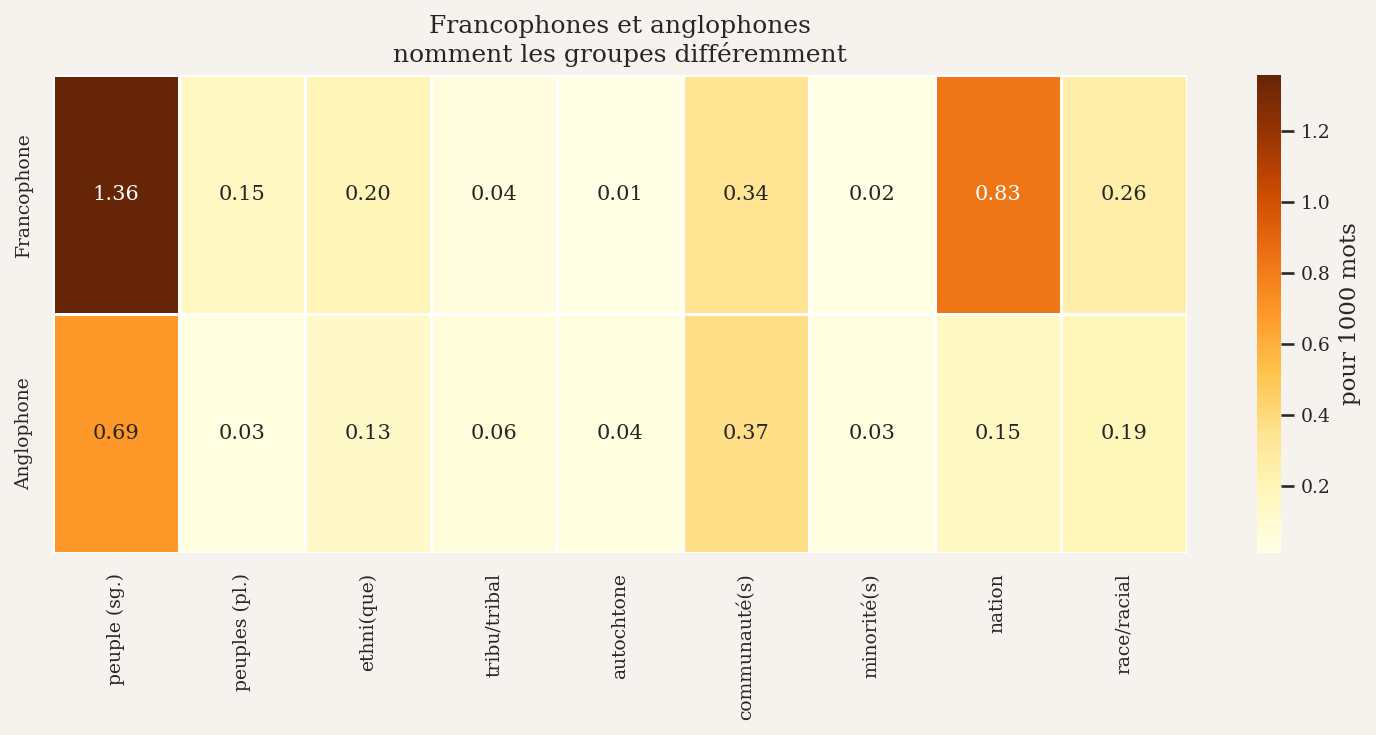

Key naming contrasts (per 1000 words):
  people (sg.)             : franco=1.359  anglo=0.688  (franco>)
  peoples (pl.)            : franco=0.153  anglo=0.031  (franco>)
  ethnic                   : franco=0.196  anglo=0.128  (franco>)
  indigenous               : franco=0.008  anglo=0.040  (anglo>)
  nation (not national)    : franco=0.830  anglo=0.153  (franco>)
  race/racial              : franco=0.256  anglo=0.187  (franco>)


In [7]:
# Naming terms in English constitution texts
NAMING_TERMS_EN = [
    ('people (sg.)', r'\bpeople\b'),
    ('peoples (pl.)', r'\bpeoples\b'),
    ('ethnic', r'\bethnic\b'),
    ('tribe/tribal', r'\btrib(?:e|al)\b'),
    ('indigenous', r'\bindigenous\b'),
    ('community/ies', r'\bcommunit(?:y|ies)\b'),
    ('minority/ies', r'\bminorit(?:y|ies)\b'),
    ('nation (not national)', r'\bnation\b(?!al)'),
    ('race/racial', r'\brac(?:e|ial)\b'),
]

naming_rows = []
for country, text in texts.items():
    text_lower = text.lower()
    n_words = len(text_lower.split())
    row = {'country': country, 'fr_name': get_fr_name(country),
           'heritage': get_heritage(country), 'words': n_words}
    for label, pattern in NAMING_TERMS_EN:
        count = len(re.findall(pattern, text_lower))
        row[label] = count / n_words * 1000
    naming_rows.append(row)

naming = pd.DataFrame(naming_rows)
term_cols = [label for label, _ in NAMING_TERMS_EN]

# FIGURE 4: Heritage x naming term heatmap (Tier 1 only)
naming_t1 = naming[naming['heritage'].isin(TIER1_HERITAGES)]
heritage_naming = naming_t1.groupby('heritage')[term_cols].mean()
heritage_naming = heritage_naming.reindex([h for h in H_ORDER if h in heritage_naming.index])

for lang in ('fr', 'en'):
    hn_plot = heritage_naming.copy()
    hn_plot.index = [hl(h, lang) for h in hn_plot.index]
    hn_plot.columns = t('naming_term_labels', lang)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(hn_plot, annot=True, fmt='.2f', cmap='YlOrBr',
                linewidths=0.5, ax=ax, cbar_kws={'label': t('naming_heatmap_cbar', lang)})
    ax.set_title(t('naming_heatmap_title', lang), fontsize=12)
    ax.set_ylabel('')

    plt.tight_layout()
    save_fig(fig, 'ch1s2_naming_heatmap', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Key naming contrasts (per 1000 words):')
for term in term_cols:
    fr = naming[naming['heritage'] == 'francophone'][term].mean()
    an = naming[naming['heritage'] == 'anglophone'][term].mean()
    if abs(fr - an) > 0.03:
        direction = 'franco>' if fr > an else 'anglo>'
        print(f'  {term:25s}: franco={fr:.3f}  anglo={an:.3f}  ({direction})')

Total "peoples" occurrences (Tier 1): 78



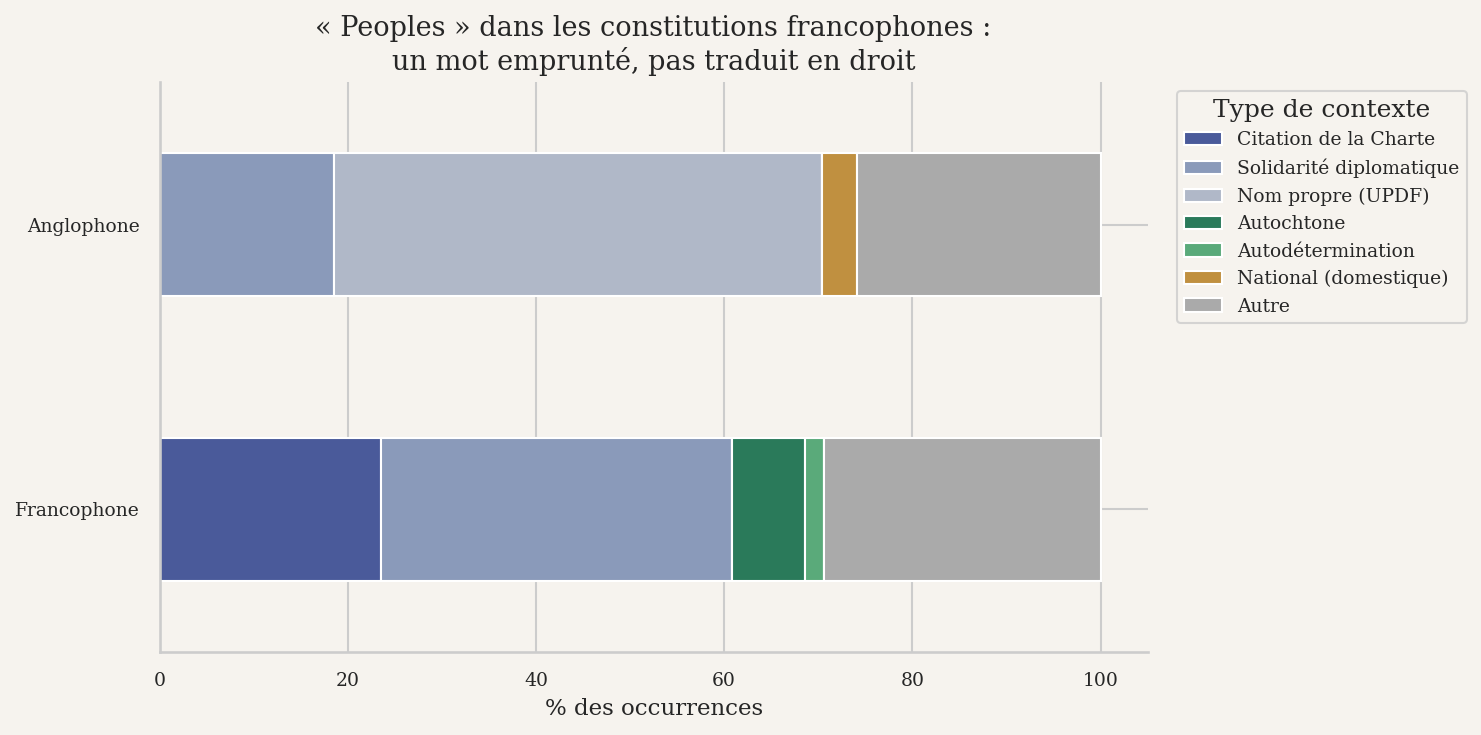


Key finding:
  Francophone "peoples" = mostly Charter citations (24%) + diplomatic solidarity (37%)
  Only CAR and Congo use it for domestic recognition of autochthonous groups.
  Anglophone "peoples" = 59% is the Uganda Peoples Defence Forces proper noun.
  Neither group uses "peoples" primarily for domestic group recognition.

Context breakdown by heritage:

  Francophone (n=51):
    Charter citation              :  12 (24%)
    Diplomatic solidarity         :  19 (37%)
    Indigenous/autochthonous      :   4 (8%)
    Self-determination            :   1 (2%)
    Other                         :  15 (29%)

  Anglophone (n=27):
    Diplomatic solidarity         :   5 (19%)
    Proper noun (UPDF)            :  14 (52%)
    National (domestic)           :   1 (4%)
    Other                         :   7 (26%)


In [8]:
# FIGURE 5: Contextual analysis of "peoples" (plural)
# Raw frequency showed francophone > anglophone, but WHAT contexts?

import re

# Classify each "peoples" occurrence by context
def classify_peoples_context(text_lower, match_start, match_end):
    start = max(0, match_start - 100)
    end = min(len(text_lower), match_end + 100)
    ctx = text_lower[start:end]
    if re.search(r'charter.{0,30}peoples|peoples.{0,10}rights\b.*charter|rights of man and of peoples', ctx):
        return 'Charter citation'
    if re.search(r'defence forces|defense forces', ctx):
        return 'Proper noun (UPDF)'
    if re.search(r'autochthon|indigenous|tribal peoples', ctx):
        return 'Indigenous/autochthonous'
    if re.search(r'self.determin', ctx):
        return 'Self-determination'
    if re.search(r'solidar|cooperat|amity|friendship|brother|fraternit|all.{0,5}peoples|peoples of the world|peoples of africa', ctx):
        return 'Diplomatic solidarity'
    if re.search(r'peoples of \w+(?:\s+\w+)?(?:\s+and|\s+while|\s+are|\s+shall)', ctx):
        return 'National (domestic)'
    return 'Other'

peoples_ctx = []
for country, text in texts.items():
    text_lower = text.lower()
    h = get_heritage(country)
    for m in re.finditer(r'\bpeoples\b', text_lower):
        cls = classify_peoples_context(text_lower, m.start(), m.end())
        peoples_ctx.append({'country': country, 'heritage': h, 'context_type': cls})

pctx = pd.DataFrame(peoples_ctx)
pctx = pctx[pctx['heritage'].isin(TIER1_HERITAGES)]
print(f'Total "peoples" occurrences (Tier 1): {len(pctx)}')
print()

# Heritage x context type
h_present = [h for h in H_ORDER if h in pctx['heritage'].values]
ct = pd.crosstab(pctx['heritage'], pctx['context_type'])
ct = ct.reindex(index=h_present)

# Context translation mapping (English internal keys -> bilingual display)
_ctx_key_map = {
    'Charter citation': 'ctx_charter',
    'Diplomatic solidarity': 'ctx_diplomatic',
    'Proper noun (UPDF)': 'ctx_proper_noun',
    'Indigenous/autochthonous': 'ctx_indigenous',
    'Self-determination': 'ctx_self_determination',
    'National (domestic)': 'ctx_national',
    'Other': 'ctx_other',
}

ctx_order = ['Charter citation', 'Diplomatic solidarity', 'Proper noun (UPDF)',
             'Indigenous/autochthonous', 'Self-determination', 'National (domestic)', 'Other']
ctx_colors = ['#4a5a9a', '#8a9aba', '#b0b8c8', '#2a7a5a', '#5aaa7a', '#c09040', '#aaaaaa']
ct_plot = ct.reindex(columns=[c for c in ctx_order if c in ct.columns], fill_value=0)

for lang in ('fr', 'en'):
    ct_lang = ct_plot.copy()
    ct_lang.index = [hl(h, lang) for h in ct_lang.index]
    ct_lang.columns = [t(_ctx_key_map[c], lang) for c in ct_lang.columns]

    ct_pct = ct_lang.div(ct_lang.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(10, 5))

    ct_pct.plot(kind='barh', stacked=True, ax=ax,
                color=[ctx_colors[ctx_order.index(c)] for c in ct_plot.columns])
    ax.set_xlabel(t('peoples_context_right_xlabel', lang))
    ax.set_title(t('peoples_context_title', lang), fontsize=13)
    ax.legend(title=t('peoples_context_legend', lang), bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

    plt.tight_layout()
    save_fig(fig, 'ch1s2_peoples_context', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

# Print summary
print('\nKey finding:')
print('  Francophone "peoples" = mostly Charter citations (24%) + diplomatic solidarity (37%)')
print('  Only CAR and Congo use it for domestic recognition of autochthonous groups.')
print('  Anglophone "peoples" = 59% is the Uganda Peoples Defence Forces proper noun.')
print('  Neither group uses "peoples" primarily for domestic group recognition.')
print()
print('Context breakdown by heritage:')
for h in h_present:
    subset = pctx[pctx['heritage'] == h]
    total = len(subset)
    if total == 0: continue
    print(f'\n  {hl(h)} (n={total}):')
    for ctx_type in ctx_order:
        n = len(subset[subset['context_type'] == ctx_type])
        if n > 0:
            print(f'    {ctx_type:30s}: {n:3d} ({n/total*100:.0f}%)')

---
## 4. Ch.5 — Self-Determination Classification (preliminary)

> **Methodological note:** This classification is keyword-based (regex). It is preliminary and requires legal validation by Alex before thesis citation.

Classify each constitution by its self-determination posture.

In [9]:
# Classify constitutions
sd_rows = []
for country, text in texts.items():
    text_lower = text.lower()
    h = get_heritage(country)
    fr_name = get_fr_name(country)

    has_sd = bool(re.search(r'self.determination', text_lower))
    has_secession = bool(re.search(r'\bsecessi', text_lower))
    has_autonomy = bool(re.search(r'\bautonomy\b|\bautonomous\b', text_lower))
    has_indivisible = bool(re.search(r'\bindivisible\b', text_lower))

    # Extract context around self-determination mentions
    sd_contexts = []
    for m in re.finditer(r'self.determination', text_lower):
        start = max(0, m.start() - 100)
        end = min(len(text), m.end() + 100)
        sd_contexts.append(text[start:end].strip())

    # Classify posture
    if country == 'Ethiopia' and has_sd:
        posture = 'external (secession permitted)'
    elif has_sd and has_autonomy:
        posture = 'internal (self-determination + autonomy)'
    elif has_sd:
        posture = 'mentioned (context-dependent)'
    elif has_autonomy and not has_indivisible:
        posture = 'autonomy without SD language'
    elif has_indivisible and not has_autonomy:
        posture = 'indivisible (implicit prohibition)'
    elif has_indivisible and has_autonomy:
        posture = 'indivisible + autonomy (tension)'
    else:
        posture = 'silent'

    sd_rows.append({
        'country': country, 'fr_name': fr_name, 'heritage': h,
        'has_sd': has_sd, 'has_secession': has_secession,
        'has_autonomy': has_autonomy, 'has_indivisible': has_indivisible,
        'posture': posture, 'sd_contexts': sd_contexts,
    })

sd = pd.DataFrame(sd_rows)

print('Self-determination posture distribution:')
print(sd['posture'].value_counts())
print()
print(f'Constitutions mentioning self-determination: {sd["has_sd"].sum()}/54')
print(f'Constitutions with "indivisible": {sd["has_indivisible"].sum()}/54')
print(f'Constitutions with autonomy language: {sd["has_autonomy"].sum()}/54')

Self-determination posture distribution:
posture
indivisible + autonomy (tension)            14
silent                                      14
autonomy without SD language                11
indivisible (implicit prohibition)           7
internal (self-determination + autonomy)     5
mentioned (context-dependent)                2
external (secession permitted)               1
Name: count, dtype: int64

Constitutions mentioning self-determination: 8/54
Constitutions with "indivisible": 24/54
Constitutions with autonomy language: 30/54


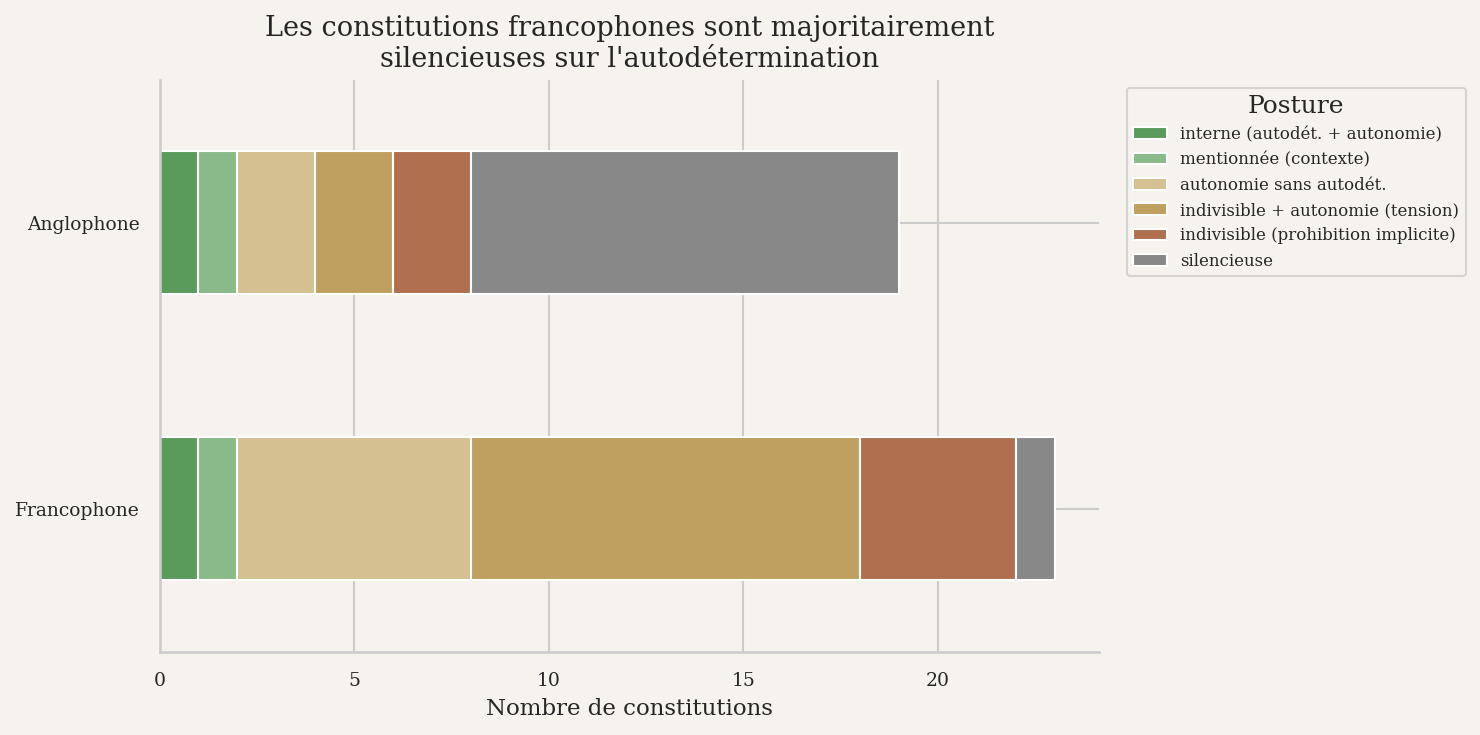

In [10]:
# FIGURE 6: Self-determination posture by heritage (stacked bar)
posture_order = [
    'external (secession permitted)',
    'internal (self-determination + autonomy)',
    'mentioned (context-dependent)',
    'autonomy without SD language',
    'indivisible + autonomy (tension)',
    'indivisible (implicit prohibition)',
    'silent',
]
posture_colors = ['#2a7a5a', '#5a9a5a', '#8aba8a', '#d4c090', '#c0a060', '#b07050', '#888888']

sd_t1 = sd[sd['heritage'].isin(TIER1_HERITAGES)]
h_present = [h for h in H_ORDER if h in sd_t1['heritage'].values]
ct = pd.crosstab(sd_t1['heritage'], sd_t1['posture'])
ct = ct.reindex(index=h_present, columns=[p for p in posture_order if p in ct.columns], fill_value=0)

# Build mapping from English posture keys to bilingual labels
_posture_labels = {p: i for i, p in enumerate(posture_order)}

for lang in ('fr', 'en'):
    sd_cats = t('sd_categories', lang)
    ct_lang = ct.copy()
    ct_lang.index = [hl(h, lang) for h in ct_lang.index]
    ct_lang.columns = [sd_cats[_posture_labels[p]] for p in ct_lang.columns]

    fig, ax = plt.subplots(figsize=(10, 5))
    ct_lang.plot(kind='barh', stacked=True, ax=ax,
            color=[posture_colors[_posture_labels[c]] for c in ct.columns])
    ax.set_xlabel(t('sd_posture_xlabel', lang))
    ax.set_title(t('sd_posture_title', lang), fontsize=13)
    ax.legend(title=t('sd_posture_legend', lang), bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

    plt.tight_layout()
    save_fig(fig, 'ch5_self_determination_posture', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

In [11]:
# List countries that mention self-determination with context
print('Countries mentioning "self-determination":')
print()
for _, row in sd[sd['has_sd']].iterrows():
    print(f'  {row["fr_name"]:35s} [{row["heritage"]:12s}] posture: {row["posture"]}')
    for ctx in row['sd_contexts'][:2]:
        # Clean up whitespace
        clean = ' '.join(ctx.split())
        print(f'    "...{clean[:120]}..."')
    print()

Countries mentioning "self-determination":

  Algérie                             [francophone ] posture: internal (self-determination + autonomy)
    "...er solidarity to all the peoples struggling for political and economic liberation, for the right of self-determination a..."

  Angola                              [lusophone   ] posture: internal (self-determination + autonomy)
    "...for sovereignty and national independence; b. Equality amongst states; c. The rights of peoples to self-determination an..."
    "...Equality amongst states; c. The rights of peoples to self-determination and independence; Right to self determination d...."

  Cap-Vert                            [lusophone   ] posture: internal (self-determination + autonomy)
    "...peoples, and peaceful coexistence. 2. The State of Cape Verde shall defend the right of peoples to self-determination Ri..."
    "...stence. 2. The State of Cape Verde shall defend the right of peoples to self-determination Right to self 

/tmp/ipykernel_59730/2840519430.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


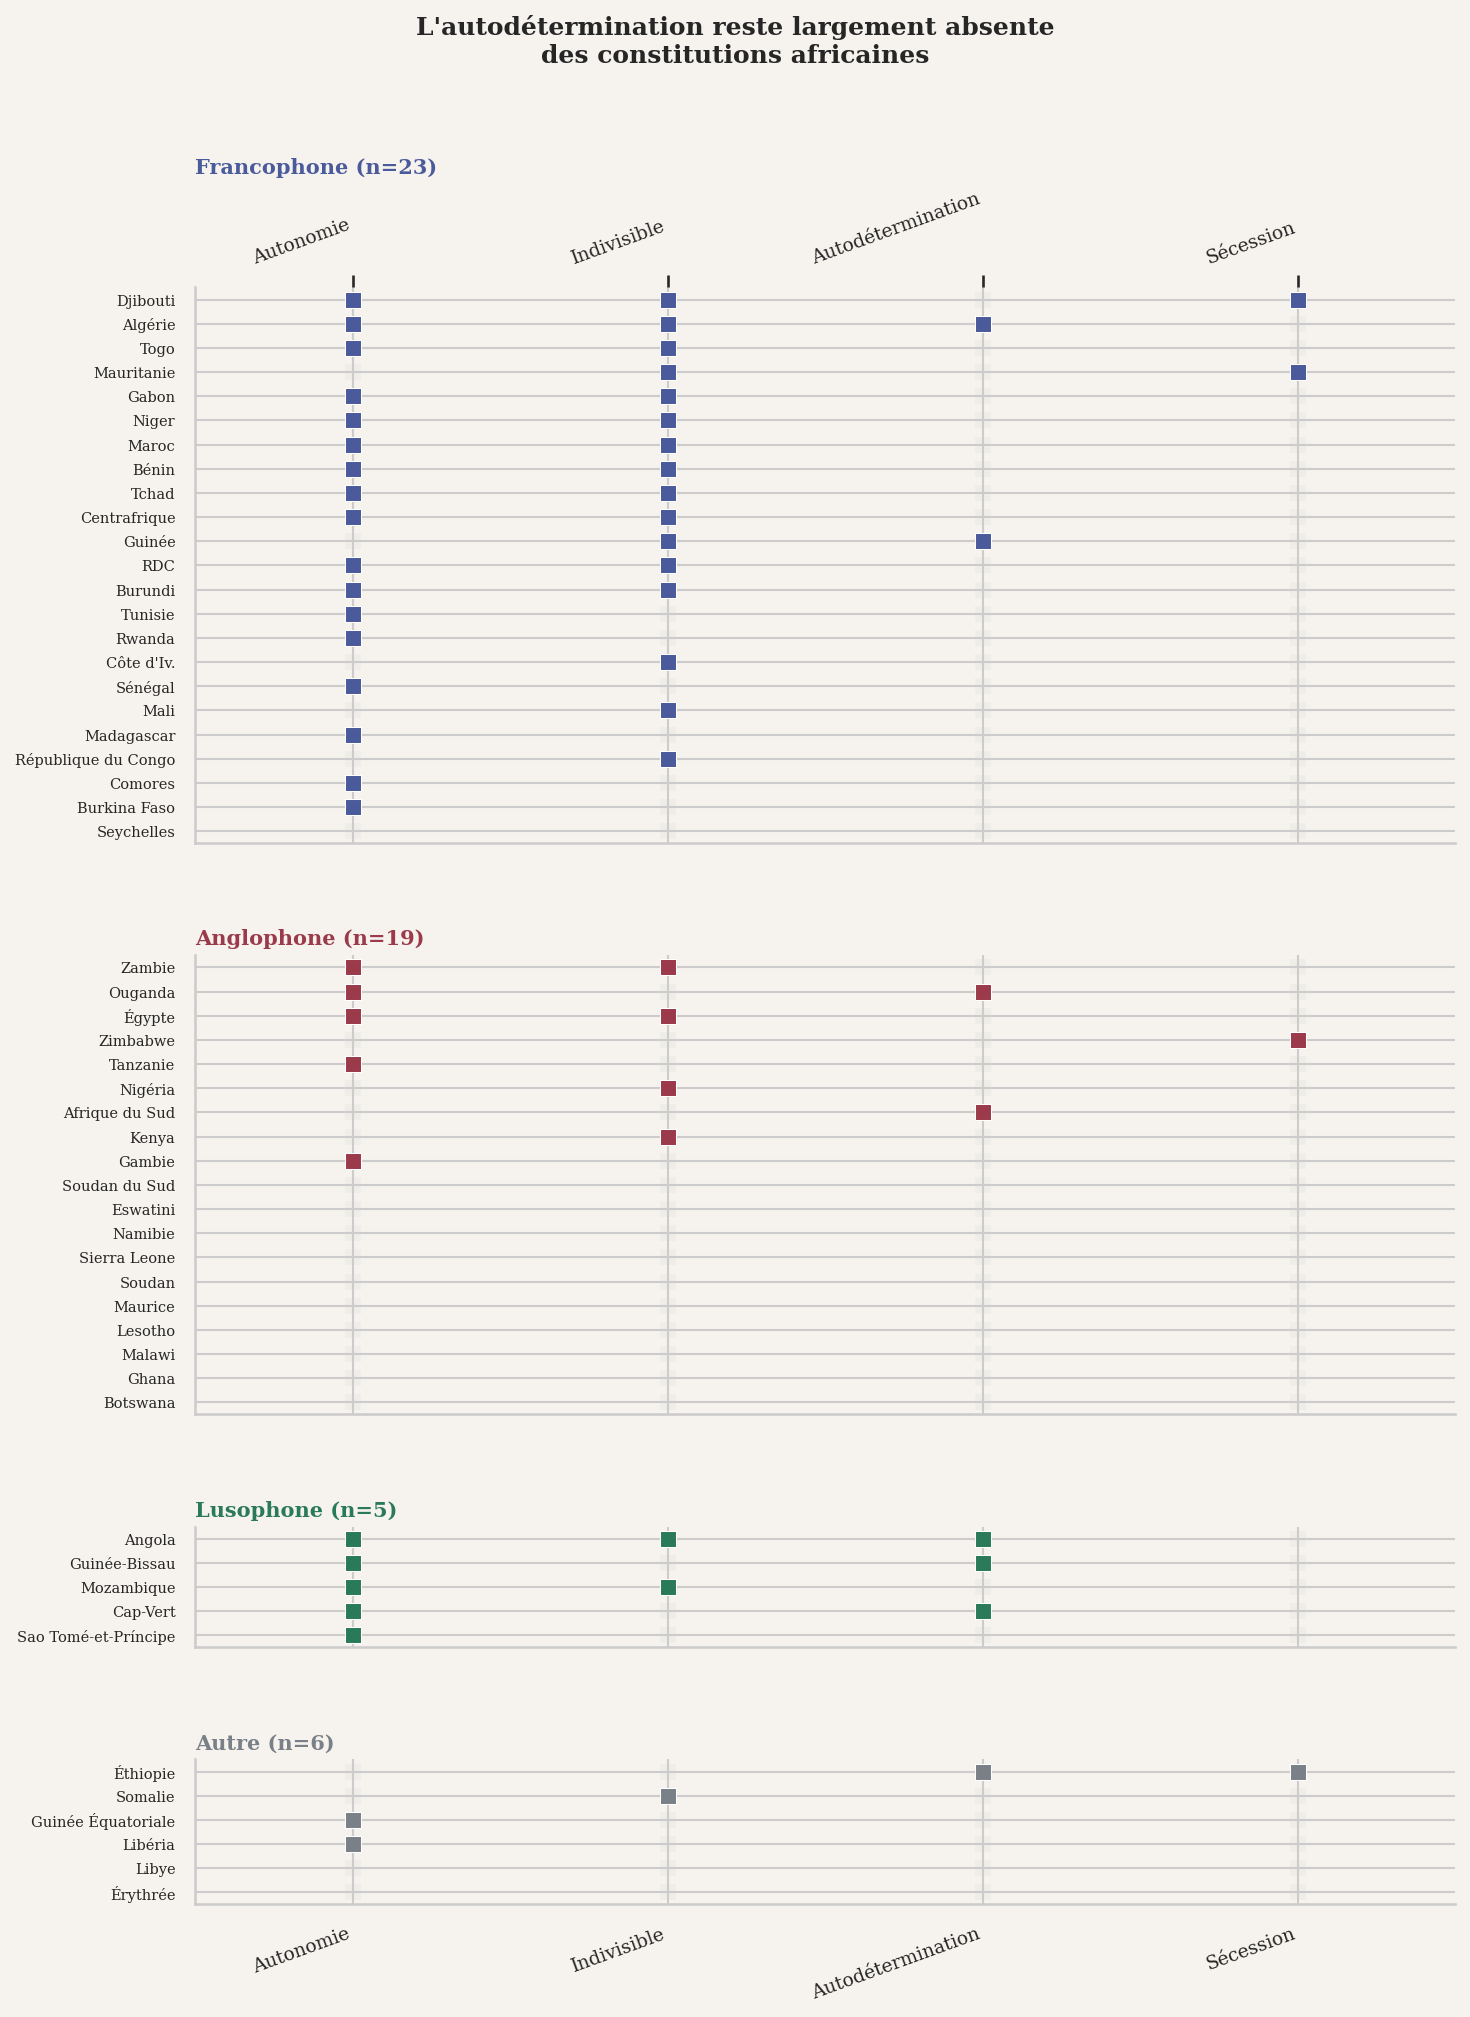

/tmp/ipykernel_59730/2840519430.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


In [12]:
# FIGURE 7: Binary flags — 4 panels by heritage group
# Include all heritage groups (francophone, anglophone, lusophone, other)
flag_cols = ['has_sd', 'has_indivisible', 'has_autonomy', 'has_secession']

# Compute criteria met per country
sd['n_criteria'] = sd[flag_cols].sum(axis=1)

heritage_groups = ['francophone', 'anglophone', 'lusophone', 'other']
# Column order: most populated first (across all countries)
col_order = sorted(flag_cols, key=lambda c: sd[c].sum(), reverse=True)

# Marker style: colored circles for True, light gray for False
MARKER_TRUE = {'marker': 's', 's': 60, 'linewidths': 0.5, 'edgecolors': 'white', 'zorder': 3}
MARKER_FALSE = {'marker': 's', 's': 60, 'linewidths': 0, 'alpha': 0.15, 'zorder': 2}

# Aggressive abbreviations for long country names
_ABBREV_MAP = {
    'République démocratique du Congo': 'RDC',
    'Rép. dém. du Congo': 'RDC',
    'République centrafricaine': 'Centrafrique',
    'Rép. centrafricaine': 'Centrafrique',
    "Côte d'Ivoire": "Côte d'Iv.",
    'Guinée équatoriale': 'Guinée éq.',
    'São Tomé-et-Príncipe': 'São Tomé',
}

def _abbrev_country(name):
    for long, short in _ABBREV_MAP.items():
        name = name.replace(long, short)
    return name

for lang in ('fr', 'en'):
    flag_labels_all = dict(zip(flag_cols, t('sd_flag_labels', lang)))
    flag_labels_ordered = [flag_labels_all[c] for c in col_order]

    # Compute actual country counts per heritage group for height_ratios
    group_counts = []
    for h in heritage_groups:
        n = len(sd[sd['heritage'] == h])
        group_counts.append(max(n, 1))  # avoid zero

    fig, axes = plt.subplots(4, 1, figsize=(12, 14),
                              gridspec_kw={'hspace': 0.35,
                                           'height_ratios': group_counts})
    fig.subplots_adjust(left=0.25)

    for ax_idx, h in enumerate(heritage_groups):
        ax = axes[ax_idx]
        # Sort by number of criteria met (most at top)
        subset = sd[sd['heritage'] == h].sort_values('n_criteria', ascending=True).copy()

        if len(subset) == 0:
            ax.set_visible(False)
            continue

        countries = [_abbrev_country(c) for c in subset['fr_name'].tolist()]
        n_countries = len(countries)

        for i, country in enumerate(countries):
            for j, col in enumerate(col_order):
                row_data = subset.iloc[i]
                if row_data[col]:
                    ax.scatter(j, i, c=HC[h], **MARKER_TRUE)
                else:
                    ax.scatter(j, i, c='#ccc', **MARKER_FALSE)

        ax.set_yticks(range(n_countries))
        ax.set_yticklabels(countries, fontsize=7)
        ax.set_xlim(-0.5, len(col_order) - 0.5)
        ax.set_ylim(-0.5, n_countries - 0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Column headers: only top of first panel and bottom of last panel
        if ax_idx == 0:
            ax.set_xticks(range(len(col_order)))
            ax.set_xticklabels(flag_labels_ordered, fontsize=9, rotation=20, ha='right')
            ax.xaxis.set_ticks_position('top')
            ax.xaxis.set_label_position('top')
        elif ax_idx == len(heritage_groups) - 1:
            ax.set_xticks(range(len(col_order)))
            ax.set_xticklabels(flag_labels_ordered, fontsize=9, rotation=20, ha='right')
        else:
            ax.set_xticks(range(len(col_order)))
            ax.set_xticklabels([])

        ax.set_title(f'{hl(h, lang)} (n={n_countries})', fontsize=10, fontweight='bold',
                     color=HC[h], pad=8 if ax_idx == 0 else 5, loc='left')

    fig.suptitle(t('sd_flags_title', lang), fontsize=12, fontweight='bold',
                 fontfamily='serif', y=1.01)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    fig.subplots_adjust(left=0.20)
    save_fig(fig, 'ch5_sd_flags_heatmap', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

---
## 5. Summary

In [13]:
print('=' * 60)
print('M2 SUMMARY — Constitutional Text Analysis')
print('=' * 60)

print(f'\n  Figures saved to: {FIG_DIR.resolve()}')
print(f'  Total figures: {len(list(FIG_DIR.glob("*.pdf")))}')
print()

print('  Ch.1 S1 — Preamble rhetoric:')
fr_bal = pa[pa['heritage'] == 'francophone']['balance'].mean()
an_bal = pa[pa['heritage'] == 'anglophone']['balance'].mean()
print(f'    Francophone balance: {fr_bal:+.1f} ({"identity" if fr_bal > 0 else "sovereignty"}-dominant)')
print(f'    Anglophone balance: {an_bal:+.1f} ({"identity" if an_bal > 0 else "sovereignty"}-dominant)')
print(f'    "indivisible": {indiv[indiv["heritage"]=="francophone"]["indivisible"].mean()*100:.0f}% francophone vs {indiv[indiv["heritage"]=="anglophone"]["indivisible"].mean()*100:.0f}% anglophone')

print(f'\n  Ch.1 S2 — Naming:')
print(f'    "people" (sg): franco {naming[naming["heritage"]=="francophone"]["people (sg.)"].mean():.2f} vs anglo {naming[naming["heritage"]=="anglophone"]["people (sg.)"].mean():.2f} per 1k')
print(f'    "peoples" (pl): franco {naming[naming["heritage"]=="francophone"]["peoples (pl.)"].mean():.3f} vs anglo {naming[naming["heritage"]=="anglophone"]["peoples (pl.)"].mean():.3f} per 1k')

print(f'\n  Ch.5 — Self-determination:')
print(f'    Mentions SD: {sd["has_sd"].sum()}/54 ({sd["has_sd"].mean()*100:.0f}%)')
print(f'    Has "indivisible": {sd["has_indivisible"].sum()}/54 ({sd["has_indivisible"].mean()*100:.0f}%)')
print(f'    Only Ethiopia permits secession')

print(f'\n  Figures produced:')
for f in sorted(FIG_DIR.glob('*.pdf')):
    print(f'    {f.name}')

M2 SUMMARY — Constitutional Text Analysis

  Figures saved to: /home/victo/projects/africa-constitutions/data/figures
  Total figures: 0

  Ch.1 S1 — Preamble rhetoric:
    Francophone balance: +1.5 (identity-dominant)
    Anglophone balance: +5.8 (identity-dominant)
    "indivisible": 70% francophone vs 21% anglophone

  Ch.1 S2 — Naming:
    "people" (sg): franco 1.36 vs anglo 0.69 per 1k
    "peoples" (pl): franco 0.153 vs anglo 0.031 per 1k

  Ch.5 — Self-determination:
    Mentions SD: 8/54 (15%)
    Has "indivisible": 24/54 (44%)
    Only Ethiopia permits secession

  Figures produced:
